# 5. Feature Selection

The initial dataset, following the Feature Engineering stage, contains 659 variables. To ensure model robustness, prevent overfitting, and meet the performance requirements of the Siemens Smart Infrastructure environment, a 5 phase feature selection engine was implemented.

The objective is to filter out noise and retain only the signals with the highest predictive power and temporal stability.

## 5.1 Import Libraries

In [45]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
from src.code.class_pipeline_functions import FeatureSelection
from collections import Counter

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

## 5.2 Data checks

In [46]:
data_dir = '../data/features'

train_df = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fe.parquet'))
val_df = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fe.parquet'))

In [47]:
train_df.head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,1,SSI027,SSI02710,SSI02710,0.0,-390277.0,0.7,263.09,18201.7,32730.0,...,1.2,0.3,1.900000,0.624500,1.183333,0.657590,2.3,8.666667,0.716667,2.154332
1,2,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,263.23,18201.7,32730.0,...,1.2,0.1,2.833333,1.266228,1.508333,1.036128,4.1,42.000000,1.325000,2.597814
2,3,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,280.30,18201.7,32730.0,...,1.4,0.6,3.933333,1.222020,1.916667,1.348961,4.4,8.333333,2.016667,2.285709
3,4,SSI027,SSI02710,SSI02710,0.0,1811758.0,1.3,281.28,18201.7,53544.1,...,1.4,1.0,4.866667,0.611010,2.316667,1.609536,4.4,5.400000,2.550000,1.915666
4,5,SSI027,SSI02710,SSI02710,0.0,80112.0,1.2,293.17,18201.7,53544.1,...,1.7,1.3,5.266667,0.230940,2.683333,1.774995,4.1,4.153846,2.583333,1.530521


In [48]:
val_df.head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,44,SSI027,SSI02710,SSI02710,NaN,NaN,0.3,311.88,18743.8,88862.8,...,3.3,3.1,2.500000,0.100000,3.033333,0.367630,-0.5,0.838710,-0.533333,-1.178723
1,45,SSI027,SSI02710,SSI02710,NaN,NaN,0.4,335.65,18743.8,88862.8,...,3.0,3.4,2.566667,0.152753,3.000000,0.378994,-0.7,0.794118,-0.433333,-0.791570
2,48,SSI027,SSI02710,SSI02710,NaN,NaN,0.5,313.13,18743.8,14255.6,...,2.4,3.5,2.900000,0.100000,2.916667,0.348590,-0.7,0.800000,-0.016667,-0.334681
3,43,SSI027,SSI02710,SSI0271002,NaN,NaN,0.2,308.86,18743.8,88862.8,...,3.4,3.2,2.600000,0.264575,3.083333,0.343335,-0.8,0.750000,-0.483333,-1.990283
4,44,SSI027,SSI02710,SSI0271002,NaN,NaN,0.3,311.88,18743.8,88862.8,...,3.3,3.1,2.500000,0.100000,3.033333,0.367630,-0.5,0.838710,-0.533333,-1.178723


In [49]:
id_cols = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']
target_cols = ['Orders cons. (anon)', 'Revenue cons. (anon)']

In [50]:
main_target = 'Revenue cons. (anon)'

X_train = train_df.drop(columns=id_cols + target_cols)
y_train = train_df[main_target].fillna(0) # filling the NaNs

## 5.3 Feature Selection Strategy

The feature selection engine is designed to distill high-dimensional data into a robust set of predictors while maintaining business relevance. From an initial pool of **659 variables**, the system performs a five-stage distillation process optimized for Siemens SI sales data.

---

### Phase 0: Variance Filter
Before any correlation analysis, quasi-constant features are removed using `VarianceThreshold`. Near-zero-variance columns produce NaN Spearman correlations that `safe_spearman()` fills with 0.0, silently distorting the Phase 1 top-K ranking. Eliminating them first keeps the ranking signal clean.

---

### Phase 1 & 2: Family-Based Diversity & Intra-Family Pruning
This phase is engineered to preserve a balanced representation across different data families (Macroeconomic, Orders, and Revenue).
* **NaN-Safe Spearman Ranking:** Rank correlation is calculated using non-NaN row alignment. This is critical for industrial data where structural NaNs appear in the early periods of new product histories.
* **Per-Family Top-K Selection:** To prevent dominant variable groups from crowding out other signals, the engine selects the best $K$ lags *within each family* (e.g., best Macro lags, best Revenue lags).
* **Intra-Family Pairwise Pruning:** Redundancy checks (Pearson correlation $> 0.95$) are performed within each family independently. This ensures that a Revenue signal isn't discarded simply because it correlates with an Orders signal, preserving multi-dimensional business perspectives.

---

### Phase 3: Ensemble Consensus Voting
The engine utilizes a "democratic" voting system between **three** distinct mathematical models to find the "elite" predictors. A feature must be nominated by at least 1/2 of 3 voters to survive.

1. **LassoCV (Linear Logic):**
    * **Dual Scaling:** A `RobustScaler` is applied to both $X$ and $y$. Normalizing the target (Revenue in millions) is essential to keep the Lasso penalty space stable and avoid zeroing out valid features prematurely.
    * **Temporal Cross-Validation:** Uses a `TimeSeriesSplit` (expanding window) to validate the model. This respects the chronological order of sales data, avoiding the look-ahead bias inherent in standard K-Fold shuffling.

2. **Random Forest (Non-linear Logic):**
    * **Cumulative Importance Threshold:** Instead of a fixed count, the model uses an adaptive threshold (default 90%). It retains the minimum number of features required to reach 90% of the total Gini importance, allowing the selection to expand or contract based on the actual signal strength of the segment.

3. **Mutual Information (Non-linear & Non-monotone Logic):**
    * **Broadest Signal Coverage:** MI captures dependencies that are invisible to both Lasso (assumes linearity) and RF (relies on tree splits).
    * **Relative Threshold:** The cutoff is set as a multiplier on the mean MI score (`mi_threshold=1.0` → above-mean features only). This makes MI nominate roughly the top 50% of features by signal strength, regardless of the absolute score scale — ensuring MI is a meaningful discriminating voter rather than a blanket endorsement.

---

### Phase 4: Structural Rescue & Reproducibility
The final phase aligns the statistical output with Siemens S&OP business rules and technical stability.
* **Rescue Logic:** Key structural drivers — **Seasonality** (Month, Quarter), **Organizational Hierarchy** (Parent, Share-of-Parent) — are unconditionally included regardless of voting outcome.
* **Stable Ordering:** The final feature set is re-indexed to match the original input column order, ensuring that model training is reproducible and that feature importance interpretations remain consistent across different sessions.

---

### Final Summary
This multistage approach results in a highly distilled, high-signal dataset:
* **Initial Pool:** 659 features.
* **Filtering Efficiency:** ~84% noise reduction across 5 phases.
* **Final Set:** ~104 features

In [51]:
selector = FeatureSelection(
    horizon=1,
    lag_top_k=2,        # top-2 lags per variable family
    corr_threshold=0.95, # intra-family Pearson redundancy threshold
    min_votes=1,         # feature must be nominated by at least 1/2 of 3 voters 
    rf_cum_threshold=0.90,
    vt_threshold=0.0,    # removes only perfectly constant features (zero variance)
    mi_threshold=1.75,    # MI cutoff = 1.75x mean MI score → nominates top ~25% by signal strength
)

selector.fit(X_train, y_train)
selector.get_selection_report()

X_train_selected = selector.transform(X_train)

X_val_features = val_df.drop(columns=id_cols + target_cols)
X_val_selected = selector.transform(X_val_features)

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

Feature Selection Report

> Phase 0: VarianceThreshold: 3 variables removed
  List: France_Steel_Production, Italy_Steel_Production, United_Kingdom_Steel_Production

> Phase 1 & 2: Correlation: 267 variables removed
  Examples: China_Core_Inflation_Rate_Lag_12, China_Core_Inflation_Rate_Lag_3, China_GDP_Lag_12, China_GDP_Lag_6, China_GDP_Momentum_3_12, China_GDP_YoY_Diff, China_GDP_YoY_Ratio, China_GDP_from_Construction_Lag_1, China_GDP_from_Construction_Lag_6, China_GDP_from_Construction_Momentum_3_12...

> Phase 3: Voting: 324 variables removed
  Examples: China_Core_Inflation_Rate, China_Core_Inflation_Rate_Anomaly_12, China_Core_Inflation_Rate_Lag_1, China_Core_Inflation_Rate_Lag_6, China_Core_Inflation_Rate_Momentum_3_12, China_Core_Inflation_Rate_Rolling_Mean_12, China_Core_Inflation_Rate_Rolling_Mean_3, China_Core_Inflation_Rate_Rolling_Std_12, China_Core_Inflation_Rate_Rolling_Std_3, China_Core_Inflation_Rate_YoY_Diff...

> Structural Rescue: 41 variables rescued (added back)
 

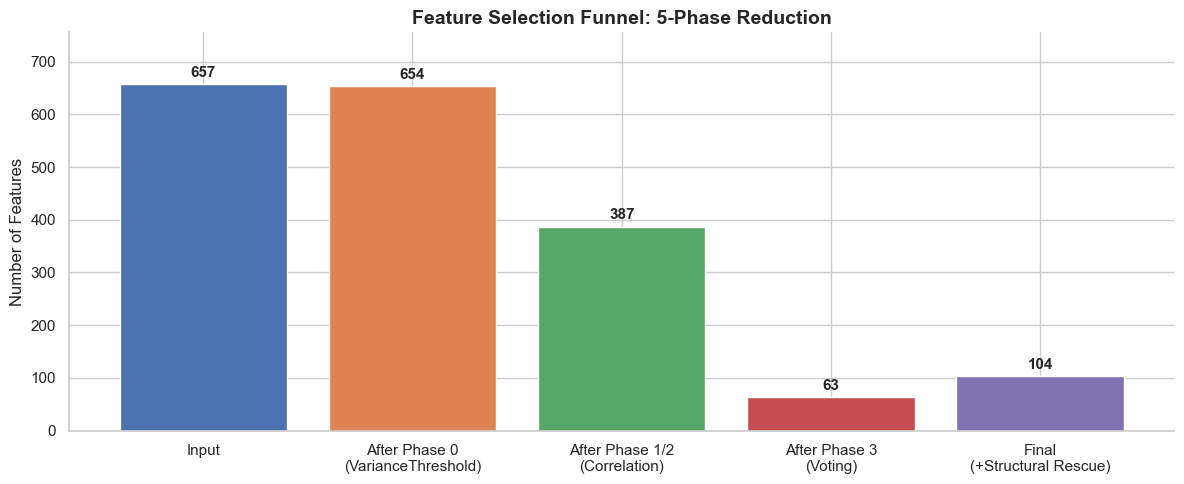

In [52]:
# Feature reduction funnel visualization (5-phase)
vt_removed   = len(selector.removal_log_.get('Phase 0: VarianceThreshold', []))
corr_removed = len(selector.removal_log_.get('Phase 1 & 2: Correlation', []))
vote_removed = len(selector.removal_log_.get('Phase 3: Voting', []))
total        = len(selector.input_features_)

phases = [
    'Input',
    'After Phase 0\n(VarianceThreshold)',
    'After Phase 1/2\n(Correlation)',
    'After Phase 3\n(Voting)',
    'Final\n(+Structural Rescue)',
]
counts = [
    total,
    total - vt_removed,
    total - vt_removed - corr_removed,
    total - vt_removed - corr_removed - vote_removed,
    len(selector.selected_features_),
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(phases, counts, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'])
ax.bar_label(bars, fmt='%d', padding=3, fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Features')
ax.set_title('Feature Selection Funnel: 5-Phase Reduction', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

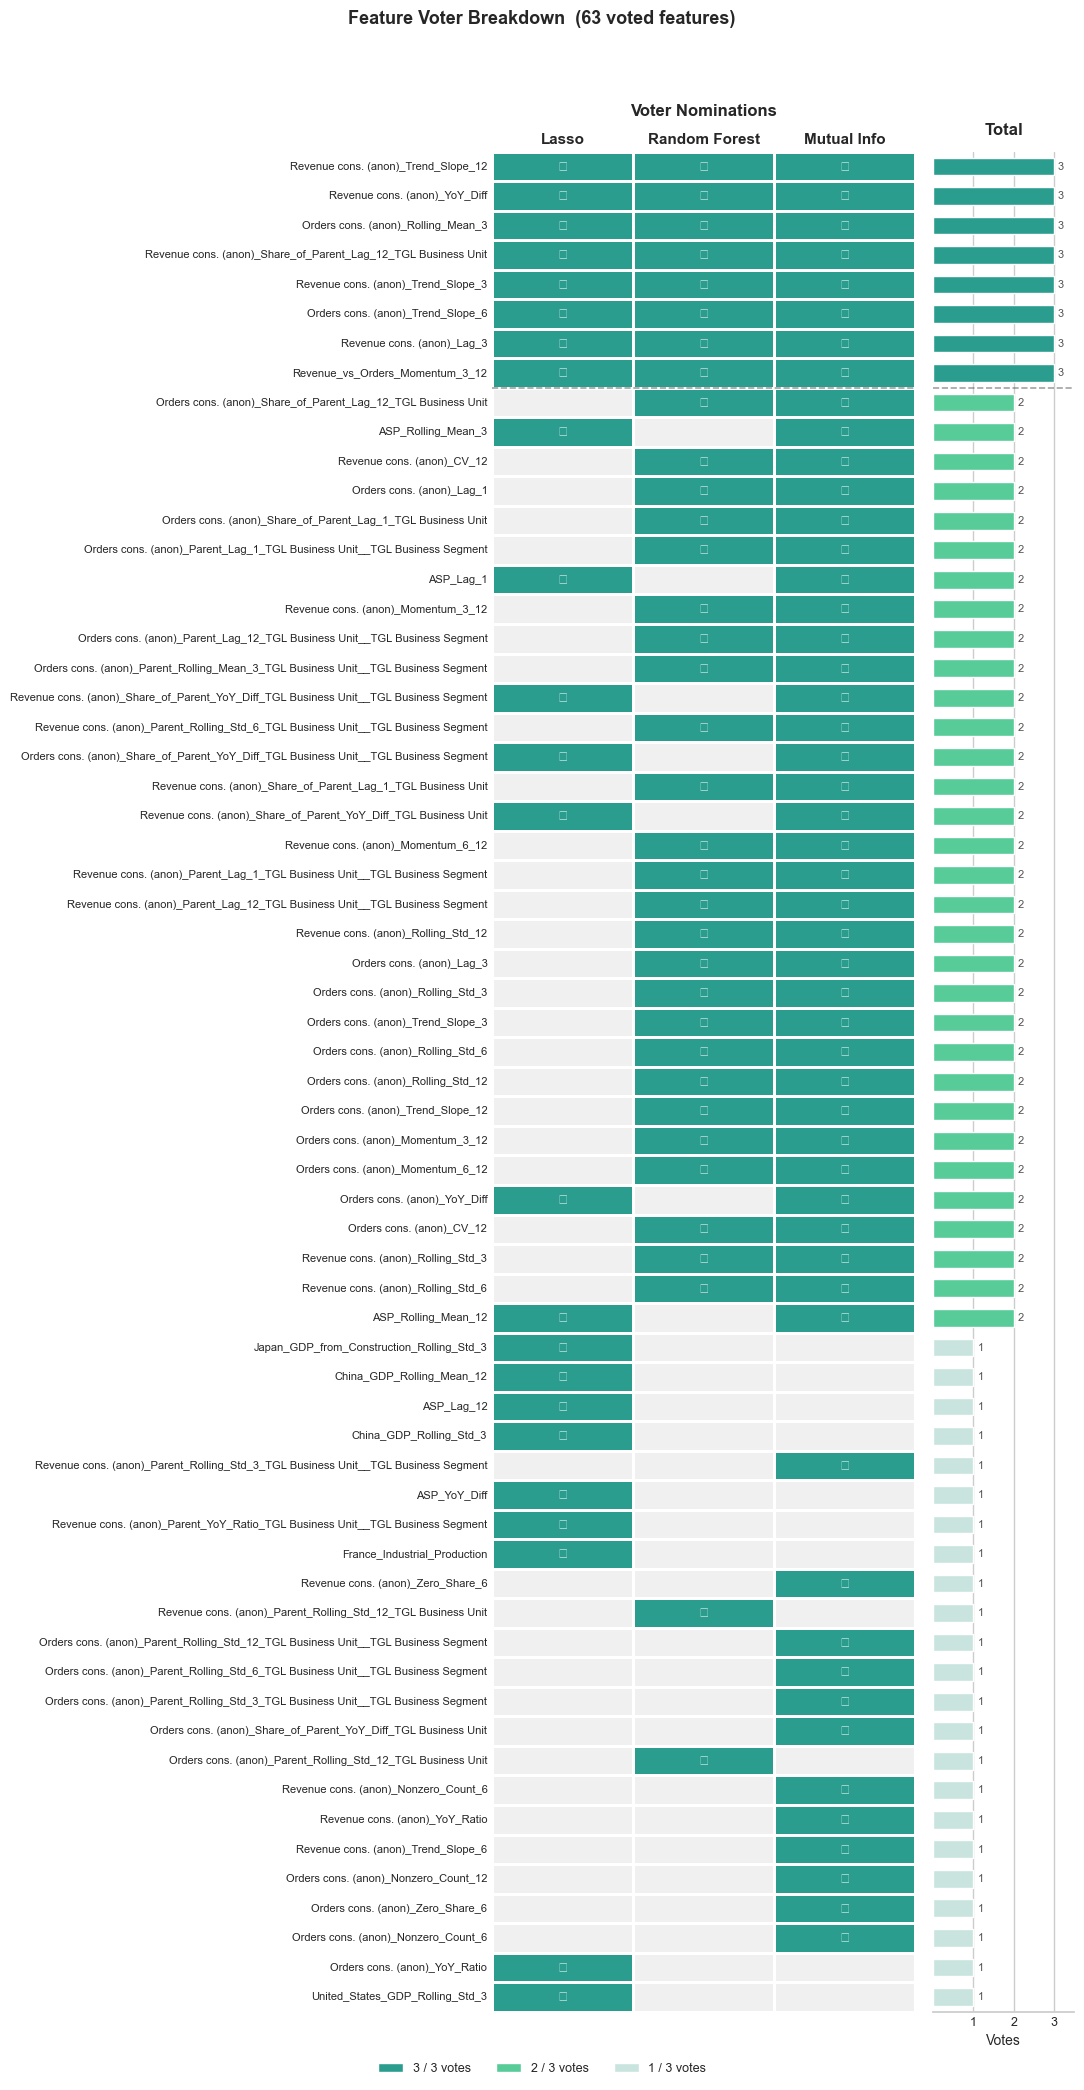

In [53]:
# Voter breakdown heatmap — voted features only (structural rescue excluded)
rescued    = set(selector.removal_log_.get('Structural Rescue', []))
voted_only = [f for f in selector.selected_features_ if f not in rescued]

voter_matrix = pd.DataFrame({
    'Lasso'        : [int(f in selector.lasso_support_) for f in voted_only],
    'Random Forest': [int(f in selector.rf_support_)    for f in voted_only],
    'Mutual Info'  : [int(f in selector.mi_support_)    for f in voted_only],
}, index=voted_only)

# Sort descending so 3-vote features appear at the top
sorted_index = voter_matrix.sum(axis=1).sort_values(ascending=False).index
voter_matrix = voter_matrix.loc[sorted_index]
vote_totals  = voter_matrix.sum(axis=1)

# Binary colormap
cmap = ListedColormap(['#f0f0f0', '#2a9d8f'])

# Annotation DataFrame
annot_df = pd.DataFrame(
    np.vectorize(lambda v: '✓' if v else '')(voter_matrix.values),
    index=voter_matrix.index,
    columns=voter_matrix.columns,
)

n_features = len(voter_matrix)
fig_height = max(8, n_features * 0.32)
fig, axes  = plt.subplots(1, 2, figsize=(11, fig_height),
                          gridspec_kw={'width_ratios': [3, 1]})

# ── Left panel: voter heatmap ──────────────────────────────────────────────────
ax_heat = axes[0]
sns.heatmap(
    voter_matrix,
    ax=ax_heat,
    cmap=cmap,
    vmin=0, vmax=1,
    linewidths=0.8,
    linecolor='white',
    cbar=False,
    annot=annot_df,
    fmt='',
    annot_kws={'size': 10, 'color': 'white', 'weight': 'bold'},
)

ax_heat.set_title('Voter Nominations', fontsize=12, fontweight='bold', pad=12)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('')
ax_heat.tick_params(axis='x', labelsize=11, length=0)
ax_heat.tick_params(axis='y', labelsize=8,  length=0)
ax_heat.xaxis.set_ticks_position('top')
ax_heat.xaxis.set_label_position('top')

for tick in ax_heat.get_xticklabels():
    tick.set_fontweight('bold')
    tick.set_fontsize(11)

# ── Right panel: vote count bar chart ─────────────────────────────────────────
ax_bar = axes[1]
bar_colors_map = {3: '#2a9d8f', 2: '#57cc99', 1: '#c9e4de'}
bar_colors     = [bar_colors_map[v] for v in vote_totals.values]

# use the same top-to-bottom order as the heatmap
y_positions = range(n_features)
bars = ax_bar.barh(
    y_positions,
    vote_totals.values,
    color=bar_colors,
    height=0.6,
    edgecolor='white',
)

# invert the y-axis so index 0 is at the top, matching heatmap
ax_bar.invert_yaxis()
ax_bar.set_ylim(n_features - 0.5, -0.5)
ax_bar.set_xlim(0, 3.5)
ax_bar.set_xticks([1, 2, 3])
ax_bar.set_xticklabels(['1', '2', '3'], fontsize=9)
ax_bar.set_xlabel('Votes', fontsize=10)
ax_bar.set_yticks([])
ax_bar.set_title('Total', fontsize=12, fontweight='bold', pad=12)
ax_bar.tick_params(length=0)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)

for bar, v in zip(bars, vote_totals.values):
    ax_bar.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(int(v)),
        va='center', fontsize=8, color='#555555',
    )

# Separator line between 3-vote and 2-vote groups
sorted_vals = list(vote_totals.values)
n_three     = sum(v == 3 for v in sorted_vals)
n_two       = sum(v == 2 for v in sorted_vals)

if n_three > 0 and n_two > 0:
    sep_y = n_three  # boundary after all 3-vote rows (from the top)
    ax_heat.axhline(y=sep_y, color='#555555', linewidth=1.2,
                    linestyle='--', alpha=0.55)
    ax_bar.axhline(y=sep_y - 0.5, color='#555555', linewidth=1.2,
                   linestyle='--', alpha=0.55)

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor='#2a9d8f', label='3 / 3 votes'),
    Patch(facecolor='#57cc99', label='2 / 3 votes'),
    Patch(facecolor='#c9e4de', label='1 / 3 votes'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=9,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    f'Feature Voter Breakdown  ({len(voted_only)} voted features)',
    fontsize=13, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

In [54]:
print(f"Final selected features ({X_train_selected.shape[1]}):\n")
print(list(X_train_selected.columns))

Final selected features (104):

['France_Industrial_Production', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'Quarter_sin', 'Quarter_cos', 'Orders cons. (anon)_Lag_1', 'Orders cons. (anon)_Lag_3', 'Orders cons. (anon)_Rolling_Mean_3', 'Orders cons. (anon)_Rolling_Std_3', 'Orders cons. (anon)_Trend_Slope_3', 'Orders cons. (anon)_Rolling_Std_6', 'Orders cons. (anon)_Trend_Slope_6', 'Orders cons. (anon)_Rolling_Std_12', 'Orders cons. (anon)_Trend_Slope_12', 'Orders cons. (anon)_Momentum_3_12', 'Orders cons. (anon)_Momentum_6_12', 'Orders cons. (anon)_YoY_Diff', 'Orders cons. (anon)_YoY_Ratio', 'Orders cons. (anon)_CV_12', 'Orders cons. (anon)_Months_Since_Last_Nonzero', 'Orders cons. (anon)_Nonzero_Count_6', 'Orders cons. (anon)_Zero_Share_6', 'Orders cons. (anon)_Nonzero_Count_12', 'Orders cons. (anon)_Zero_Share_12', 'Revenue cons. (anon)_Lag_3', 'Revenue cons. (anon)_Rolling_Std_3', 'Revenue cons. (anon)_Trend_Slope_3', 'Revenue cons. (anon)_Rolling_Std_6', 'Revenue cons. (anon)_Tren

In [55]:
# Save the feature-selected datasets
output_dir = '../data/features'

train_df_selected = pd.concat([train_df[id_cols + target_cols].reset_index(drop=True),
                                X_train_selected.reset_index(drop=True)], axis=1)
val_df_selected   = pd.concat([val_df[id_cols + target_cols].reset_index(drop=True),
                                X_val_selected.reset_index(drop=True)],   axis=1)

train_df_selected.to_parquet(os.path.join(output_dir, 'training_subsegment_fs.parquet'), index=False)
val_df_selected.to_parquet(os.path.join(output_dir,   'validation_subsegment_fs.parquet'), index=False)

print(f"Saved training:   {train_df_selected.shape}")
print(f"Saved validation: {val_df_selected.shape}")

Saved training:   (4237, 110)
Saved validation: (715, 110)


## (5.4 Core Feature Families Visualization)

> **Note:** The analysis below is purely exploratory and has no effect on the final selected feature set.  
> The saved parquets (`_fs.parquet`) are determined solely by the main selector in section 5.3.  
> This cell runs independent per-subsegment fits to check whether the selected features generalize  
> across different demand profiles — it is a robustness validation, not a selection step.

To ensure the selected features generalize beyond any single business subsegment, we run the full 5 phase feature selection pipeline independently across multiple subsegments and measure the **feature persistence**. The goal is to identify a **universal feature set**, predictors that are consistently selected regardless of the subsegment's specific demand pattern.

**Methodology:**
1. The `FeatureSelection` pipeline is fitted independently on each subsegment (minimum 24 months of history required).
2. Features selected across all runs are aggregated, and their **selection frequency** is computed as a percentage of successful subsegment fits.
3. **Universal features** are defined as those appearing in ≥70% of subsegments, ensuring broad cross-segment relevance.
4. An **elite subset** (≥90% frequency) is further extracted and categorized into interpretable business families (Macroeconomic, Hierarchy, Seasonality, Pricing, Autoregressive, etc.) to visualize the compositional balance of the core signal.

This analysis validates that the feature selection pipeline produces a stable, interpretable predictor set rather than overfitting to the idiosyncrasies of individual subsegments.

In [56]:
all_selected_features = []
subsegments_to_test = train_df['TGL Business Subsegment'].unique()

for seg in subsegments_to_test:
    mask = train_df['TGL Business Subsegment'] == seg
    X_seg = X_train[mask]
    y_seg = y_train[mask]
    
    if len(X_seg) < 24: 
        continue
    
    # min_votes=1 intentional: robustness scan, not final selection.
    # vt_threshold and mi_threshold use class defaults (0.0 and 0.01).
    sel = FeatureSelection(horizon=1, lag_top_k=2, corr_threshold=0.90, min_votes=1)
    
    try:
        sel.fit(X_seg, y_seg)
        all_selected_features.append(sel.selected_features_)
    except:
        continue

flat_list = [item for sublist in all_selected_features for item in sublist]
feature_freq = Counter(flat_list)

# universal features are the ones present in 70% of the cases
threshold = len(all_selected_features) * 0.7
universal_features = [f for f, count in feature_freq.items() if count >= threshold]

print(f"\nTotal processed subsegments: {len(all_selected_features)}")
print(f"Universal features found: {len(universal_features)}")
print(universal_features)


Total processed subsegments: 94
Universal features found: 220
['China_Core_Inflation_Rate', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Steel_Production', 'France_Core_Inflation_Rate', 'France_Exports', 'France_GDP', 'France_Industrial_Production', 'Germany_Industrial_Production_Mom', 'Italy_Exports', 'Japan_Exports', 'Japan_Industrial_Production', 'Japan_Industrial_Production_Mom', 'Japan_Steel_Production', 'Switzerland_Industrial_Production_Mom', 'United_Kingdom_GDP_from_Manufacturing', 'United_States_Industrial_Production', 'United_States_Steel_Production', 'Month', 'Quarter', 'Month_sin', 'Month_cos', 'Quarter_sin', 'Quarter_cos', 'Revenue cons. (anon)_Trend_Slope_3', 'Revenue cons. (anon)_Rolling_Std_6', 'Revenue cons. (anon)_Trend_Slope_6', 'Revenue cons. (anon)_YoY_Diff', 'Orders cons. (anon)_Parent_Lag_1_TGL Business Unit', 'Orders cons. (anon)_Parent_Lag_12_TGL Business Unit', 'Orders cons. (anon)_Parent_YoY_Diff_TGL Busine

**Result:** Out of the subsegments, 94 met the minimum history requirement (≥24 months). From those, 220 features were consistently selected in at least 70% of cases, indicating a strong core signal across diverse demand profiles.


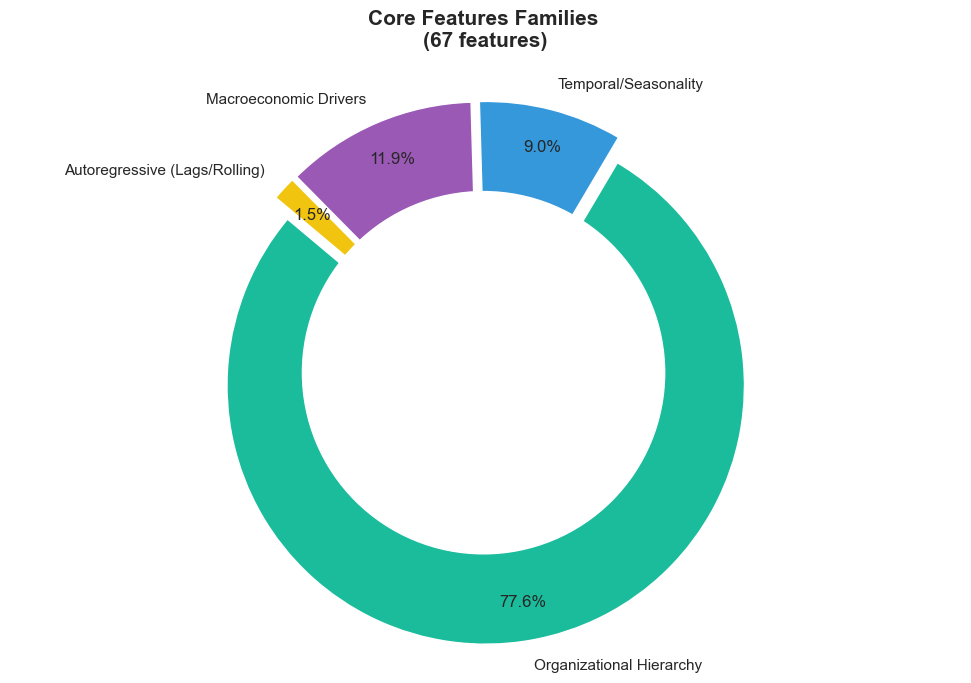

In [57]:
n_real_success = len(all_selected_features) 

def categorize(feature):
    # macro indicators
    countries = ['China', 'Germany', 'France', 'United_States', 'Italy', 'Japan', 'Switzerland', 'United_Kingdom']
    if any(ctry in feature for ctry in countries):
        return 'Macroeconomic Drivers'
    
    # hierarchy
    if 'Parent' in feature or 'Share_of_Parent' in feature:
        return 'Organizational Hierarchy'
    
    # calendar & seasonality
    if any(kw in feature for kw in ['Month', 'Quarter', 'sin', 'cos']):
        return 'Temporal/Seasonality'
    
    # pricing dynamics — includes Revenue_vs_Orders cross-feature (same family as ASP)
    if 'ASP' in feature or 'Revenue_vs_Orders' in feature:
        return 'Pricing (ASP)'
    
    # intermittency & volatility metrics (Momentum removed — it's a trend signal, not inventory)
    if any(kw in feature for kw in ['Zero_Share', 'Months_Since_Last_Nonzero', 'Nonzero_Count', 'CV_12']):
        return 'Inventory & Performance Metrics'
    
    # autoregressive features — added Momentum (trend signal) and YoY_ (was falling to 'Other')
    if any(kw in feature for kw in ['Lag_', 'Rolling_', 'Trend_Slope', 'Momentum', 'YoY_']):
        return 'Autoregressive (Lags/Rolling)'
    
    # fallback
    return 'Other Internal Dynamics'

if n_real_success == 0:
    print("Error.")
else:
    
    # uncomment to exclude structurally rescued features
    # rescued_keywords = ['Parent', 'Share_of_Parent', 'Month', 'Quarter', 'sin', 'cos']
    # voted_freq = {f: c for f, c in feature_freq.items()
    #               if not any(kw in f for kw in rescued_keywords)}

    # full_freq = pd.DataFrame.from_dict(voted_freq, orient='index', columns=['count'])




    full_freq = pd.DataFrame.from_dict(feature_freq, orient='index', columns=['count'])
    full_freq['percentage'] = (full_freq['count'] / n_real_success) * 100
    full_freq = full_freq.sort_values('percentage', ascending=False)

    threshold_elite = 90 
    elite_features = full_freq[full_freq['percentage'] >= threshold_elite].index

    if len(elite_features) == 0:
        print(f"No feature reached a value of {threshold_elite}%.")
        print(f"The max is {full_freq['percentage'].max():.1f}%.")
    else:
        # categorizing features into families
        elite_categories = [categorize(f) for f in elite_features]
        elite_counts = Counter(elite_categories)

        # graph
        plt.figure(figsize=(10, 7))
        colors = ['#1abc9c', '#3498db', '#9b59b6', '#f1c40f', '#e67e22', '#FF69B4']
        
        plt.pie(
            elite_counts.values(), 
            labels=elite_counts.keys(), 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors[:len(elite_counts)],
            pctdistance=0.85,
            explode=[0.05] * len(elite_counts)
        )

        centre_circle = plt.Circle((0,0), 0.70, fc='white')
        fig = plt.gcf()
        fig.gca().add_artist(centre_circle)

        plt.title(f'Core Features Families \n({len(elite_features)} features)', 
                  fontsize=15, fontweight='bold', pad=20)
        plt.axis('equal') 
        plt.tight_layout()
        plt.show()